## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('02_full_audit_matrix.csv')
df.head()

,hash,headline,summary,source,published,link,feed,llm1_label,llm1_confidence,llm2_label,llm2_confidence,word_count,has_currency,raw_digit_count,ticker_acronym_count,hyphen_count,gb_label,gb_confidence
0,db6cebd41790dc2dab8f9119f79efcda,Reliance Industries Q4 earnings: Net profit de...,NaN,Google News,"Tue, 16 Jun 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMimgJBV...,gnews/Reliance Industries earnings p,negative,0.80,negative,0.85,21,1,11,0,0,positive,0.424
1,7bf94b2a07ca0c04dd4b67c5fc8be12c,Reliance Industries Limited. . A year of histo...,NaN,Google News,"Sat, 13 Jun 2026 03:30:31 GMT",https://news.google.com/rss/articles/CBMi7AFBV...,gnews/Reliance Industries earnings p,positive,0.99,positive,1.00,41,1,11,1,0,positive,0.669
2,498935b4694419db67ade3691645b660,Reliance Industries posts record annual profit...,NaN,Google News,"Fri, 24 Apr 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMijgJBV...,gnews/Reliance Industries earnings p,positive,0.80,positive,0.85,14,0,0,0,0,neutral,0.775
3,56096081bfc72679f8c3fa7f0c2f175d,Reliance Industries FY26 Revenue Rises 9.8% to...,NaN,Google News,"Thu, 28 May 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMiogFBV...,gnews/Reliance Industries earnings p,positive,0.95,positive,0.95,11,0,8,0,0,neutral,0.637
4,77384488a55b219b38c23e2cecd833f1,Reliance Industries Q4 results: Net profit fal...,NaN,Google News,"Sat, 25 Apr 2026 07:00:00 GMT",https://news.google.com/rss/articles/CBMi6wFBV...,gnews/Reliance Industries earnings p,negative,0.60,negative,0.85,12,0,6,1,0,neutral,0.689


In [25]:
df.drop(columns=['hash','summary','source','published','link','feed'], inplace=True)

In [5]:
df.head()

,headline,llm1_label,llm1_confidence,llm2_label,llm2_confidence,word_count,has_currency,raw_digit_count,ticker_acronym_count,hyphen_count,gb_label,gb_confidence
0,Reliance Industries Q4 earnings: Net profit de...,negative,0.80,negative,0.85,21,1,11,0,0,positive,0.424
1,Reliance Industries Limited. . A year of histo...,positive,0.99,positive,1.00,41,1,11,1,0,positive,0.669
2,Reliance Industries posts record annual profit...,positive,0.80,positive,0.85,14,0,0,0,0,neutral,0.775
3,Reliance Industries FY26 Revenue Rises 9.8% to...,positive,0.95,positive,0.95,11,0,8,0,0,neutral,0.637
4,Reliance Industries Q4 results: Net profit fal...,negative,0.60,negative,0.85,12,0,6,1,0,neutral,0.689


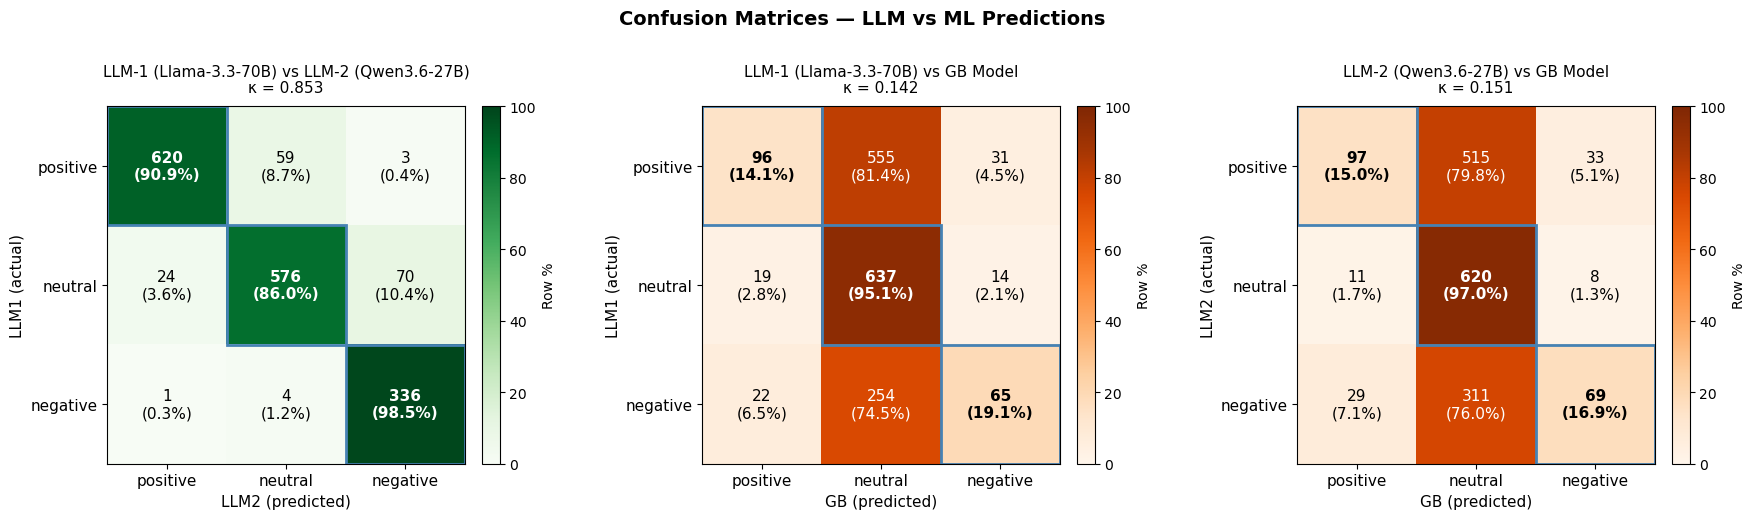

In [7]:

import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, cohen_kappa_score

labels = ["positive", "neutral", "negative"]

pairs = [
    ("LLM-1 (Llama-3.3-70B) vs LLM-2 (Qwen3.6-27B)", "llm1_label", "llm2_label", "Greens"),
    ("LLM-1 (Llama-3.3-70B) vs GB Model",             "llm1_label", "gb_label",   "Oranges"),
    ("LLM-2 (Qwen3.6-27B) vs GB Model",               "llm2_label", "gb_label",   "Oranges"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — LLM vs ML Predictions", fontsize=14, fontweight="bold", y=1.02)

for ax, (title, col1, col2, cmap) in zip(axes, pairs):
    cm = confusion_matrix(df[col1], df[col2], labels=labels)
    row_totals = cm.sum(axis=1, keepdims=True)
    cm_pct = cm / row_totals * 100  # row-normalised %

    kappa = cohen_kappa_score(df[col1], df[col2])

    im = ax.imshow(cm_pct, cmap=cmap, vmin=0, vmax=100)

    # ── Cell annotations ─────────────────────────────────────────
    for i in range(3):
        for j in range(3):
            color = "white" if cm_pct[i, j] > 55 else "black"
            ax.text(j, i,
                    f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)",
                    ha="center", va="center",
                    fontsize=11, color=color,
                    fontweight="bold" if i == j else "normal")

    # ── Axes ──────────────────────────────────────────────────────
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel(col2.replace("_label", "").upper() + " (predicted)", fontsize=11)
    ax.set_ylabel(col1.replace("_label", "").upper() + " (actual)",    fontsize=11)
    ax.set_title(f"{title}\nκ = {kappa:.3f}", fontsize=11, pad=10)

    # ── Highlight diagonal ────────────────────────────────────────
    for i in range(3):
        ax.add_patch(plt.Rectangle(
            (i - 0.5, i - 0.5), 1, 1,
            fill=False, edgecolor="steelblue", linewidth=2
        ))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row %")

plt.tight_layout()
plt.show()


In [75]:
df1 = pd.read_csv('02_full_audit_matrix(mc).csv')
df1.shape

(3100, 13)

In [85]:
import pandas as pd

df = pd.read_csv("02_full_audit_matrix(mc).csv")
print(f"Starting rows: {len(df)}\n")

# ═══════════════════════════════════════════════════════════════
# FILTER 1 — Remove pure roundup / daily digest headlines
# These bundle multiple unrelated stocks — no single sentiment
# ═══════════════════════════════════════════════════════════════
ROUNDUP_PREFIXES = [
    "stocks to watch today", "sensex today", "taking stock",
    "closing bell", "opening bell", "chart of the day",
    "trade spotlight", "first tick", "trade setup",
    "momentum buzz", "buzzing stocks", "momentum stocks",
    "currency check", "commodity corner", "week ahead",
    "dalal street week", "live:", "business in the week",
    "broader indices", "nifty, sensex", "sensex, nifty",
    "asian stocks", "asian markets","closing bell:", "commodity corner:",
    "taking stock:", "sensex jumps","market at close", "market at open", "top gainers",
"top losers", "top stocks", "stocks in news",
"10 things to know", "5 things to know",
"market wrap", "pre-market", "mid-day market",
"nifty outlook", "technical view", "technical picks",
"f&o cues", "fii dii", "results today",
"earnings today", "q4 results", "q3 results",
]

roundup_mask = df["headline"].str.lower().str.strip().apply(
    lambda h: any(h.startswith(p) for p in ROUNDUP_PREFIXES)
)
print(f"Filter 1 — Roundup headlines     : {roundup_mask.sum()} removed")
df = df[~roundup_mask].copy()

# ═══════════════════════════════════════════════════════════════
# FILTER 2 — Remove opinion columns / rhetorical questions
# These are analyst commentary, not factual news events
# ═══════════════════════════════════════════════════════════════
OPINION_SIGNALS = [
    "guruspeak", "beyond price", "weekly tactical",
    "how should you trade", "how should one look",
    "hungry for more", "will ge vernova", "will bharat",
    "a defensive stock", "finding dynamic support",
    "patience over perfection", "what's driving",
    "what is driving", "here's what analysts",
    "should you buy", "should you sell", "should you invest",
"time to buy", "time to sell", "buy or sell",
"hold or sell", "hold or buy",
"analysts say", "analysts expect", "analysts see",
"target price of rs",  # pure analyst target, no news
"initiates coverage", "initiates with",
]

opinion_mask = df["headline"].str.lower().apply(
    lambda h: any(sig in h for sig in OPINION_SIGNALS)
)
print(f"Filter 2 — Opinion columns       : {opinion_mask.sum()} removed")
df = df[~opinion_mask].copy()

# ═══════════════════════════════════════════════════════════════
# FILTER 3 — Remove purely non-Indian global news
# Key distinction: "OMCs gain on Iran deal" = Indian stocks
#                 "SpaceX IPO breaks records" = not Indian
# Strategy: flag global keywords BUT only remove if NO Indian
#           signal (Indian company/exchange/regulator) present
# ═══════════════════════════════════════════════════════════════
GLOBAL_ONLY_SIGNALS = [
    "spacex", "elon musk", "nikkei", "japan's",
    "china stock", "china ai", "baidu", "wall street bankers",
    "tokyo looks", "asia's ipo boom", "openai challengers",
    "us-iran peace", "iran war risks", "strait of hormuz",
    "middle-east peace deal", "us-iran deal",
    "hedge funds reopen", "asian stocks edge",
    "asian stocks hit", "asian stocks rise","spacex frenzy",
      "spacex surges", "spacex by the numbers",
    "wall street's jaw-dropper", "goldman sachs lowers oil",
    "china stock gauge","crude oil falls", "crude oil rises",   # unless tied to OMCs
"gold prices", "silver prices",          # unless tied to Indian jewellers
"dollar index", "us dollar rises",
"fed rate", "us fed",                    # unless "India impact"
"bitcoin", "ethereum", "crypto",
"nasdaq", "dow jones", "s&p 500",
]

# Indian market signals — if present, keep the headline
INDIAN_SIGNALS = [
    "nse", "bse", "nifty", "sensex", "sebi", "rbi",
    "india", "indian", "rs.", "rs ", "₹", "crore", "lakh",
    "dalal street", "nifty50",
]

def is_global_only(headline):
    h_lower = headline.lower()
    has_global = any(sig in h_lower for sig in GLOBAL_ONLY_SIGNALS)
    if not has_global:
        return False
    has_indian = any(sig in h_lower for sig in INDIAN_SIGNALS)
    return not has_indian   # remove only if global AND no Indian signal

global_mask = df["headline"].apply(is_global_only)
print(f"Filter 3 — Pure global news      : {global_mask.sum()} removed")
df = df[~global_mask].copy()

# ═══════════════════════════════════════════════════════════════
# FILTER 4 — Remove "LIVE:" broadcast headlines
# These are real-time market commentary, not discrete news events
# ═══════════════════════════════════════════════════════════════
live_mask = df["headline"].str.strip().str.upper().str.startswith("LIVE:")
print(f"Filter 4 — Live broadcast        : {live_mask.sum()} removed")
df = df[~live_mask].copy()

# ═══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════
print(f"\n{'='*50}")
print(f"  CLEANING SUMMARY")
print(f"{'='*50}")
print(f"  Starting rows  : 3100")
print(f"  Remaining rows : {len(df)}")
print(f"  Removed        : {3100 - len(df)} ({(3100-len(df))/3100*100:.1f}%)")

if "llm1_label" in df.columns:
    print(f"\n  LLM-1 label distribution:")
    print(df["llm1_label"].value_counts().to_string())

df.reset_index(drop=True).to_csv("mc_cleaned.csv", index=False)
print(f"\n  Saved → mc_cleaned.csv")

Starting rows: 3100

Filter 1 — Roundup headlines     : 216 removed
Filter 2 — Opinion columns       : 38 removed
Filter 3 — Pure global news      : 77 removed
Filter 4 — Live broadcast        : 0 removed

  CLEANING SUMMARY
  Starting rows  : 3100
  Remaining rows : 2769
  Removed        : 331 (10.7%)

  LLM-1 label distribution:
llm1_label
positive    1343
neutral      798
negative     628

  Saved → mc_cleaned.csv


In [86]:
import pandas as pd
import re

df = pd.read_csv("mc_cleaned.csv")
print(f"Starting: {len(df)}")
report = {}

# ── Filter A — Pure broker target price ───────────────────────────
# Pattern: "Buy/Sell CompanyName; target of Rs X: BrokerName"
# These are pure recommendations, no news event
mask_a = df['headline'].str.lower().str.match(
    r'^(buy|sell|hold|add|reduce|accumulate|neutral on)\s+\w+'
)
report['broker_target'] = mask_a.sum()
df = df[~mask_a].copy()

# ── Filter B — Rhetorical questions ───────────────────────────────
# Questions are opinion/commentary, not factual news
# Exception: keep if they contain a clear event signal
EVENT_SIGNALS = ['results', 'profit', 'loss', 'revenue', 'q4', 'q3',
                 'quarterly', 'merger', 'acquisition', 'ipo', 'listing']

def is_junk_question(h):
    if not h.strip().endswith('?'):
        return False
    # Keep if it contains a clear news event signal
    h_lower = h.lower()
    return not any(sig in h_lower for sig in EVENT_SIGNALS)

mask_b = df['headline'].apply(is_junk_question)
report['rhetorical_q'] = mask_b.sum()
df = df[~mask_b].copy()

# ── Filter C — Check/list/digest headlines ────────────────────────
CHECK_PATTERNS = [
    r'check\s+(dates|timings|details|gmp|price\s+band|all\s+details)',
    r'all\s+you\s+need\s+to\s+know',
    r'everything\s+you\s+need',
    r'check\s+.*\bagenda\b',
    r'here\s+are\s+\d+',
    r'top\s+\d+\s+stocks',
]
mask_c = df['headline'].str.lower().apply(
    lambda h: any(re.search(p, h) for p in CHECK_PATTERNS)
)
report['check_list'] = mask_c.sum()
df = df[~mask_c].copy()

# ── Filter D — Pure global news (no Indian signal) ────────────────
GLOBAL_ONLY = [
    "wall street", "nasdaq", "dow jones", "s&p 500",
    "china stock gauge", "nikkei", "tsmc's local",
    "bitcoin", "ethereum",
]
INDIAN_SIGNALS = [
    "india", "indian", "nse", "bse", "nifty", "sensex",
    "sebi", "rbi", "rs.", "rs ", "₹", "crore", "lakh",
]

def is_pure_global(h):
    h_lower = h.lower()
    has_global = any(s in h_lower for s in GLOBAL_ONLY)
    if not has_global:
        return False
    return not any(s in h_lower for s in INDIAN_SIGNALS)

mask_d = df['headline'].apply(is_pure_global)
report['pure_global'] = mask_d.sum()
df = df[~mask_d].copy()

# ── Filter E — Remaining roundup style ───────────────────────────
ROUNDUP_CONTAINS = [
    "| closing bell", "| opening bell",
    "top gainers and losers",
    "among top gainers today",  # generic market movement
]
# Only remove if it's the main subject, not a company-specific mention
mask_e = df['headline'].str.lower().apply(
    lambda h: any(p in h for p in ROUNDUP_CONTAINS) and
    not any(company in h.lower() for company in
            ['sbi', 'hdfc', 'reliance', 'tcs', 'infosys',
             'icici', 'axis', 'kotak', 'wipro', 'hcl'])
)
report['roundup_remaining'] = mask_e.sum()
df = df[~mask_e].copy()

# ── Summary ────────────────────────────────────────────────────────
print("="*50)
print("  ADDITIONAL CLEANING SUMMARY")
print("="*50)
for reason, count in report.items():
    print(f"  {reason:<25} : {count} removed")
print(f"  {'─'*35}")
print(f"  Remaining rows         : {len(df)}")
print(f"  Total removed this pass: {sum(report.values())}")
print("="*50)

df.reset_index(drop=True).to_csv("mc_cleaned_v2.csv", index=False)
print("Saved → mc_cleaned_v2.csv")

Starting: 2769
  ADDITIONAL CLEANING SUMMARY
  broker_target             : 153 removed
  rhetorical_q              : 76 removed
  check_list                : 33 removed
  pure_global               : 6 removed
  roundup_remaining         : 6 removed
  ───────────────────────────────────
  Remaining rows         : 2495
  Total removed this pass: 274
Saved → mc_cleaned_v2.csv


In [88]:
import pandas as pd
import re

df = pd.read_csv("mc_cleaned_v2.csv")
print(f"Starting: {len(df)}")
report = {}

# ── Filter F — "Here's why" starting headlines only ───────────────
mask_f = df['headline'].str.lower().str.strip().str.startswith(
    ("here's why", "here is why")
)
report['heres_why_openers'] = mask_f.sum()
df = df[~mask_f].copy()

# ── Filter G — IPO GMP tracking / allotment admin ─────────────────
# Remove grey market premium tracking and IPO admin headlines
# Keep GMP = Good Manufacturing Practice (pharma/mfg news)
def is_gmp_junk(h):
    h_lower = h.lower()
    # Grey market premium tracking
    if 'grey market premium' in h_lower:
        return True
    # "check latest gmp" or "check gmp" = grey market tracking
    if re.search(r'check\s+(latest\s+)?gmp', h_lower):
        return True
    # IPO allotment admin combined with GMP
    if 'allotment' in h_lower and 'gmp' in h_lower:
        return True
    # IPO subscription status tracking
    if re.search(r'ipo.*\d+(\.\d+)?\s*times\s+subscription', h_lower):
        return True
    return False

mask_g = df['headline'].apply(is_gmp_junk)
report['ipo_gmp_admin'] = mask_g.sum()
df = df[~mask_g].copy()

# ── Summary ────────────────────────────────────────────────────────
print("="*50)
print("  FINAL CLEANING PASS")
print("="*50)
for reason, count in report.items():
    print(f"  {reason:<25} : {count} removed")
print(f"  {'─'*35}")
print(f"  Final rows : {len(df)}")
print("="*50)

df.reset_index(drop=True).to_csv("mc_cleaned_final.csv", index=False)
print("Saved → mc_cleaned_final.csv")

Starting: 2495
  FINAL CLEANING PASS
  heres_why_openers         : 2 removed
  ipo_gmp_admin             : 34 removed
  ───────────────────────────────────
  Final rows : 2459
Saved → mc_cleaned_final.csv


# Combining two datasets

In [90]:
import pandas as pd
import hashlib

# ── File paths — update these to match your actual filenames ──────
RSS_AUDIT = "02_full_audit_matrix.csv"
MC_AUDIT  = "mc_cleaned_final.csv"
OUTPUT    = "combined_final_dataset.csv"


# ── Step 1: Majority Vote Function ────────────────────────────────
def apply_majority_vote(filepath, source_name):
    df = pd.read_csv(filepath)

    # Drop rows where any labeler failed
    before = len(df)
    df = df.dropna(subset=['llm1_label', 'llm2_label', 'gb_label']).copy()
    print(f"\n{source_name}:")
    print(f"  Total rows       : {before}")
    print(f"  After dropna     : {len(df)}")

    # Majority vote — 2 out of 3 must agree
    def majority_label(row):
        votes = [row['llm1_label'], row['llm2_label'], row['gb_label']]
        for label in set(votes):
            if votes.count(label) >= 2:
                return label
        return None  # all 3 disagree → reject

    df['final_label']  = df.apply(majority_label, axis=1)
    df['data_source']  = source_name

    # Drop rows where all 3 disagreed
    accepted = df[df['final_label'].notna()].copy()
    rejected = df[df['final_label'].isna()].copy()

    print(f"  Accepted         : {len(accepted)}")
    print(f"  Rejected (all 3 disagree): {len(rejected)}")
    print(f"  Label split      : {accepted['final_label'].value_counts().to_dict()}")

    return accepted


# ── Step 2: Load and apply majority vote to both ──────────────────
rss = apply_majority_vote(RSS_AUDIT, "rss_gnews")
mc  = apply_majority_vote(MC_AUDIT,  "moneycontrol")


# ── Step 3: Combine ───────────────────────────────────────────────
combined = pd.concat([rss, mc], ignore_index=True)
print(f"\nCombined before dedup : {len(combined)}")


# ── Step 4: Deduplicate by hash ───────────────────────────────────
# If hash column doesn't exist, generate it from headline text
if 'hash' not in combined.columns:
    combined['hash'] = combined['headline'].apply(
        lambda x: hashlib.md5(str(x).lower().encode()).hexdigest()
    )

# Keep first occurrence — RSS takes priority over MC for duplicates
# since RSS was fetched first (change to 'last' if you prefer MC)
before_dedup = len(combined)
combined = combined.drop_duplicates(subset='hash', keep='first')\
                   .reset_index(drop=True)
dupes_removed = before_dedup - len(combined)
print(f"Duplicates removed    : {dupes_removed}")
print(f"Combined after dedup  : {len(combined)}")


# ── Step 5: Keep only clean columns needed for fine-tuning ────────
keep = [
    'headline',         # text input for FinBERT
    'final_label',      # label: positive / negative / neutral
    'data_source',      # rss_gnews or moneycontrol
    'llm1_label',       # for audit/analysis
    'llm1_confidence',
    'llm2_label',
    'llm2_confidence',
    'gb_label',
    'gb_confidence',
]
combined = combined[[c for c in keep if c in combined.columns]]


# ── Step 6: Final summary ─────────────────────────────────────────
print("\n" + "="*50)
print("  FINAL COMBINED DATASET")
print("="*50)
print(f"  Total rows       : {len(combined)}")
print(f"\n  Label distribution:")
for label, count in combined['final_label'].value_counts().items():
    pct = count / len(combined) * 100
    bar = '█' * int(pct / 2)
    print(f"    {label:<10} {count:>5}  {pct:>5.1f}%  {bar}")
print(f"\n  Source breakdown:")
for src, count in combined['data_source'].value_counts().items():
    print(f"    {src:<20} {count:>5}")
print(f"\n  Duplicates removed : {dupes_removed}")
print("="*50)


# ── Step 7: Save ──────────────────────────────────────────────────
combined.to_csv(OUTPUT, index=False)
print(f"\n  Saved → {OUTPUT}")


rss_gnews:
  Total rows       : 1693
  After dropna     : 1693
  Accepted         : 1678
  Rejected (all 3 disagree): 15
  Label split      : {'neutral': 717, 'positive': 621, 'negative': 340}

moneycontrol:
  Total rows       : 2459
  After dropna     : 2459
  Accepted         : 2438
  Rejected (all 3 disagree): 21
  Label split      : {'positive': 1042, 'neutral': 801, 'negative': 595}

Combined before dedup : 4116
Duplicates removed    : 7
Combined after dedup  : 4109

  FINAL COMBINED DATASET
  Total rows       : 4109

  Label distribution:
    positive    1660   40.4%  ████████████████████
    neutral     1515   36.9%  ██████████████████
    negative     934   22.7%  ███████████

  Source breakdown:
    moneycontrol          2431
    rss_gnews             1678

  Duplicates removed : 7

  Saved → combined_final_dataset.csv


In [14]:
import pandas as pd
import numpy as np
import hashlib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("combined_final_dataset.csv")
print(f"Starting rows: {len(df)}")
print(f"Label split: {df['final_label'].value_counts().to_dict()}\n")

report = {}  # track how many each filter removes


# ═══════════════════════════════════════════════════════════════════
# FILTER 1 — Remove truncated/cropped headlines
# Moneycontrol rows cropped at ~42 words, often mid-sentence
# ═══════════════════════════════════════════════════════════════════
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))

truncated = (
    # ends with ellipsis
    df['headline'].str.strip().str.endswith(('...', '…'))  |
    # long AND ends mid-word (no punctuation at end)
    (
        (df['word_count'] >= 38) &
        ~df['headline'].str.strip().str.endswith(
            ('.', '!', '?', '"', "'")
        )
    )
)
report['truncated'] = truncated.sum()
df = df[~truncated].copy()
print(f"Filter 1 — Truncated headlines removed : {report['truncated']}")
print(f"  Remaining: {len(df)}")


# ═══════════════════════════════════════════════════════════════════
# FILTER 2 — Remove rows where LLM-2 disagrees
# LLM-2 (Qwen) is your most reliable annotator (never < 0.65 conf,
# κ=0.84 with LLM-1). If it disagrees with the majority label,
# that row is genuinely ambiguous — drop it.
# ═══════════════════════════════════════════════════════════════════
llm2_disagrees = df['llm2_label'] != df['final_label']
report['llm2_disagrees'] = llm2_disagrees.sum()
df = df[~llm2_disagrees].copy()
print(f"\nFilter 2 — LLM-2 disagrees removed     : {report['llm2_disagrees']}")
print(f"  Remaining: {len(df)}")


# ═══════════════════════════════════════════════════════════════════
# FILTER 3 — Remove low confidence rows
# If LLM-1 AND LLM-2 are both below 0.75 on this row,
# neither was sure — drop it (stricter than your original 0.65)
# ═══════════════════════════════════════════════════════════════════
for col in ['llm1_confidence', 'llm2_confidence', 'gb_confidence']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

both_llm_uncertain = (
    (df['llm1_confidence'] < 0.75) &
    (df['llm2_confidence'] < 0.75)
)
report['low_confidence'] = both_llm_uncertain.sum()
df = df[~both_llm_uncertain].copy()
print(f"\nFilter 3 — Both LLMs low confidence     : {report['low_confidence']}")
print(f"  Remaining: {len(df)}")


# ═══════════════════════════════════════════════════════════════════
# FILTER 4 — Remove near-duplicate headlines (semantic similarity)
# Catches same story rephrased slightly across sources
# Uses TF-IDF cosine similarity — rows > 0.85 similar → keep one
# ═══════════════════════════════════════════════════════════════════
print(f"\nFilter 4 — Near-duplicate removal (cosine > 0.85)...")

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
tfidf_matrix = vectorizer.fit_transform(df['headline'].tolist())

# Process in chunks to avoid memory issues on large datasets
CHUNK = 500
to_drop = set()
indices = df.index.tolist()

for start in range(0, len(indices), CHUNK):
    chunk_idx = indices[start:start + CHUNK]
    chunk_vec = tfidf_matrix[start:start + CHUNK]
    # Compare this chunk against everything after it
    rest_vec  = tfidf_matrix[start:]
    sims      = cosine_similarity(chunk_vec, rest_vec)

    for i, idx_i in enumerate(chunk_idx):
        if idx_i in to_drop:
            continue
        for j in range(i + 1, sims.shape[1]):
            if sims[i, j] > 0.85:
                # Drop the one with lower average LLM confidence
                idx_j = indices[start + j]
                if idx_j in to_drop:
                    continue
                conf_i = (df.at[idx_i, 'llm1_confidence'] +
                          df.at[idx_i, 'llm2_confidence']) / 2
                conf_j = (df.at[idx_j, 'llm1_confidence'] +
                          df.at[idx_j, 'llm2_confidence']) / 2
                to_drop.add(idx_j if conf_i >= conf_j else idx_i)

report['near_dupes'] = len(to_drop)
df = df[~df.index.isin(to_drop)].copy()
print(f"  Near-duplicates removed              : {report['near_dupes']}")
print(f"  Remaining: {len(df)}")


# ═══════════════════════════════════════════════════════════════════
# FILTER 5 — Balance classes
# Undersample to the median class size so no class dominates
# Keeps highest-confidence rows within each class
# ═══════════════════════════════════════════════════════════════════
print(f"\nFilter 5 — Class balancing...")
print(f"  Before: {df['final_label'].value_counts().to_dict()}")

# Add average LLM confidence for sorting
df['avg_llm_conf'] = (df['llm1_confidence'] + df['llm2_confidence']) / 2

# Target: match the minority class size (don't inflate, only trim)
min_class_size = df['final_label'].value_counts().min()
# (using min because we want to keep the dataset balanced and not lose too many samples from the majority classes)
target = int(df['final_label'].value_counts().min())

balanced_parts = []
for label in ['positive', 'negative', 'neutral']:
    subset = df[df['final_label'] == label].copy()
    if len(subset) > target:
        # Keep highest confidence rows
        subset = subset.nlargest(target, 'avg_llm_conf')
    balanced_parts.append(subset)

df = pd.concat(balanced_parts, ignore_index=True)
report['balancing'] = sum(
    max(0, df['final_label'].value_counts().get(l, 0) - target)
    for l in ['positive', 'negative', 'neutral']
)
print(f"  Target per class : {target}")
print(f"  After: {df['final_label'].value_counts().to_dict()}")
print(f"  Remaining: {len(df)}")


# ═══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  CLEANING SUMMARY")
print("="*55)
print(f"  Original rows          : 4,742")
print(f"  Truncated removed      : {report['truncated']}")
print(f"  LLM-2 disagrees        : {report['llm2_disagrees']}")
print(f"  Low confidence         : {report['low_confidence']}")
print(f"  Near-duplicates        : {report['near_dupes']}")
print(f"  Balancing trim         : trimmed to {target}/class")
print(f"  ─────────────────────────────────────────")
print(f"  Final rows             : {len(df)}")
print(f"\n  Final label split:")
for label, count in df['final_label'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"    {label:<10} {count:>5}  {pct:>5.1f}%  {bar}")
print(f"\n  Source breakdown:")
if 'data_source' in df.columns:
    print(df['data_source'].value_counts().to_dict())
print("="*55)


# ═══════════════════════════════════════════════════════════════════
# SAVE — drop internal columns, keep only what FinBERT needs
# ═══════════════════════════════════════════════════════════════════
keep = ['headline', 'final_label', 'data_source',
        'llm1_label', 'llm1_confidence',
        'llm2_label', 'llm2_confidence',
        'gb_label',   'gb_confidence']

df = df[[c for c in keep if c in df.columns]]
df.to_csv("Cleaned_balanced(label_only).csv", index=False)
print(f"\n  Saved → combined_cleaned_final.csv")

Starting rows: 4109
Label split: {'positive': 1660, 'neutral': 1515, 'negative': 934}

Filter 1 — Truncated headlines removed : 26
  Remaining: 4083

Filter 2 — LLM-2 disagrees removed     : 189
  Remaining: 3894

Filter 3 — Both LLMs low confidence     : 0
  Remaining: 3894

Filter 4 — Near-duplicate removal (cosine > 0.85)...
  Near-duplicates removed              : 50
  Remaining: 3844

Filter 5 — Class balancing...
  Before: {'positive': 1632, 'neutral': 1306, 'negative': 906}
  Target per class : 906
  After: {'positive': 906, 'negative': 906, 'neutral': 906}
  Remaining: 2718

  CLEANING SUMMARY
  Original rows          : 4,742
  Truncated removed      : 26
  LLM-2 disagrees        : 189
  Low confidence         : 0
  Near-duplicates        : 50
  Balancing trim         : trimmed to 906/class
  ─────────────────────────────────────────
  Final rows             : 2718

  Final label split:
    positive     906   33.3%  ████████████████
    negative     906   33.3%  ███████████████

# SEntFin Dataset cleaning

In [18]:
data = pd.read_csv('SEntFiN-v1.1.csv')

In [19]:
data.head()

,S No.,Title,Decisions,Words
0,1,SpiceJet to issue 6.4 crore warrants to promoters,"{""SpiceJet"": ""neutral""}",8
1,2,MMTC Q2 net loss at Rs 10.4 crore,"{""MMTC"": ""neutral""}",8
2,3,"Mid-cap funds can deliver more, stay put: Experts","{""Mid-cap funds"": ""positive""}",8
3,4,Mid caps now turn into market darlings,"{""Mid caps"": ""positive""}",7
4,5,"Market seeing patience, if not conviction: Pra...","{""Market"": ""neutral""}",8


In [20]:
data['Words'].max()

23

In [21]:
import json

# ═══════════════════════════════════════════════════════════════
# STEP 1 — Parse the Decisions column (JSON string → dict)
# ═══════════════════════════════════════════════════════════════
def parse_decisions(s):
    try:
        return json.loads(s.replace("'", '"'))
    except:
        return {}

data["decisions_dict"] = data["Decisions"].apply(parse_decisions)

# ═══════════════════════════════════════════════════════════════
# STEP 2 — Keep ONLY single-entity rows
# Remove any headline that has more than 1 entity
# ══════════════════════════════════════════
data["entity_count"] = data["decisions_dict"].apply(len)

print(f"Single-entity rows : {(data['entity_count'] == 1).sum()}")
print(f"Multi-entity rows  : {(data['entity_count'] > 1).sum()}")
print(f"Zero-entity rows   : {(data['entity_count'] == 0).sum()}\n")

data = data[data["entity_count"] == 1].copy()
print(f"After single-entity filter: {len(data)} rows")

# ═══════════════════════════════════════════════════════════════
# STEP 3 — Extract label from the JSON dict
# {"SpiceJet": "neutral"} → "neutral"
# ═══════════════════════════════════════════════════════════════
data["final_label"] = data["decisions_dict"].apply(
    lambda d: list(d.values())[0].lower().strip()
)

# Keep only valid labels
valid = ["positive", "negative", "neutral"]
before = len(data)
data = data[data["final_label"].isin(valid)].copy()
print(f"Invalid labels removed: {before - len(data)}")

# ═══════════════════════════════════════════════════════════════
# STEP 4 — Word length filter (using existing Words column)
# ═══════════════════════════════════════════════════════════════
print(f"\nWord count stats before filter:")
print(data["Words"].describe())

MIN_WORDS = 6
MAX_WORDS = 40

before = len(data)
data = data[(data["Words"] >= MIN_WORDS) & (data["Words"] <= MAX_WORDS)].copy()
print(f"\nWord length filter ({MIN_WORDS}–{MAX_WORDS} words):")
print(f"  Removed : {before - len(data)} rows")
print(f"  Remaining: {len(data)} rows")

# ═══════════════════════════════════════════════════════════════
# STEP 5 — Deduplication (exact headline)
# ═══════════════════════════════════════════════════════════════
before = len(data)
data = data.drop_duplicates(subset="Title").copy()
print(f"\nDuplicates removed: {before - len(data)}")

# ═══════════════════════════════════════════════════════════════
# STEP 6 — Keep only what FinBERT needs
# Drop entity name, S No., Decisions, Words columns
# ═══════════════════════════════════════════════════════════════
data = data[["Title", "final_label"]].copy()
data.columns = ["headline", "sentiment"]
data = data.reset_index(drop=True)

# ═══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ════════════════════════════════════
print("  SENTFIN CLEANING SUMMARY")
print("="*50)
print(f"  Final rows : {len(data)}")
print(f"\n  Label distribution:")
for label, count in data["sentiment"].value_counts().items():
    pct = count / len(data) * 100
    bar = "█" * int(pct / 2)
    print(f"    {label:<10} {count:>5}  ({pct:.1f}%)  {bar}")

Single-entity rows : 7903
Multi-entity rows  : 2836
Zero-entity rows   : 14

After single-entity filter: 7903 rows
Invalid labels removed: 0

Word count stats before filter:
count    7903.000000
mean        9.741617
std         2.376709
min         3.000000
25%         8.000000
50%        10.000000
75%        11.000000
max        23.000000
Name: Words, dtype: float64

Word length filter (6–40 words):
  Removed : 140 rows
  Remaining: 7763 rows

Duplicates removed: 51
  SENTFIN CLEANING SUMMARY
  Final rows : 7712

  Label distribution:
    positive    2781  (36.1%)  ██████████████████
    neutral     2603  (33.8%)  ████████████████
    negative    2328  (30.2%)  ███████████████


In [24]:
data.to_csv("sentfin_cleaned.csv", index=False)

In [22]:
data.head()

,headline,sentiment
0,SpiceJet to issue 6.4 crore warrants to promoters,neutral
1,MMTC Q2 net loss at Rs 10.4 crore,neutral
2,"Mid-cap funds can deliver more, stay put: Experts",positive
3,Mid caps now turn into market darlings,positive
4,"Market seeing patience, if not conviction: Pra...",neutral


In [25]:
import pandas as pd
import re

df = pd.read_csv("sentfin_cleaned.csv")
print(f"Starting: {len(df)}")
report = {}

# ── Filter 1 — Non-Indian / global content ────────────────────────
GLOBAL_REMOVE = [
    "hong kong shares", "asian stocks", "asia shares",
    "wall street", "nasdaq", "dow jones",
    "australian & new zealand", "australian dollar",
    "china stock", "nikkei",
]
mask1 = df['headline'].str.lower().apply(
    lambda h: any(g in h for g in GLOBAL_REMOVE)
)
report['global'] = mask1.sum()
df = df[~mask1].copy()

# ── Filter 2 — Commodity/forex roundups ───────────────────────────
COMMODITY_STARTERS = [
    "refined soya oil", "crude palm oil", "copper futures",
    "gold futures", "silver futures", "zinc futures",
    "aluminium futures", "lead futures", "nickel futures",
    "mecklai financial", "forward markets commission",
]
mask2 = df['headline'].str.lower().apply(
    lambda h: any(h.startswith(c) for c in COMMODITY_STARTERS)
)
report['commodity'] = mask2.sum()
df = df[~mask2].copy()

# ── Filter 3 — Pre-market / F&O roundup columns ───────────────────
ROUNDUP_STARTERS = [
    "pre-market:", "f&o tracker:", "heard on the street",
    "analyst view: market wrap", "five things to watch",
    "recommend wait and watch",
]
mask3 = df['headline'].str.lower().apply(
    lambda h: any(h.startswith(r) for r in ROUNDUP_STARTERS)
)
report['roundup'] = mask3.sum()
df = df[~mask3].copy()

# ── Filter 4 — Opinion/should you ────────────────────────────────
mask4 = df['headline'].str.lower().str.contains(
    r'should you (buy|sell|invest|bet|opt)|'
    r'is it time to (buy|sell)|'
    r'time to (buy|sell)\?', regex=True
)
report['opinion'] = mask4.sum()
df = df[~mask4].copy()

# ── Filter 5 — Pure analyst target price notes ────────────────────
# Pattern: "CompanyName with target price of Rs X: AnalystName"
mask5 = (
    df['headline'].str.lower().str.contains(
        r'with target (price )?of rs \d+.*:', regex=True
    ) |
    df['headline'].str.lower().str.match(
        r'^target of rs \d+'
    )
)
report['target_price'] = mask5.sum()
df = df[~mask5].copy()

# ── Filter 6 — Commodity-specific vague short headlines ───────────
# "Gur closes steady", "Gur remains flat" etc.
COMMODITY_WORDS = [
    'gur ', 'guar ', 'jeera ', 'turmeric ', 'cardamom ',
    'mentha oil', 'castor seed', 'cotton seed',
]
mask6 = df['headline'].str.lower().apply(
    lambda h: any(c in h for c in COMMODITY_WORDS)
)
report['agri_commodity'] = mask6.sum()
df = df[~mask6].copy()

# ── Summary ────────────────────────────────────────────────────────
print("="*50)
print("  SENTFIN CLEANING SUMMARY")
print("="*50)
for reason, count in report.items():
    print(f"  {reason:<20} : {count} removed")
print(f"  {'─'*35}")
print(f"  Remaining rows : {len(df)}")
print(f"\n  Label distribution:")
for label, count in df['sentiment'].value_counts().items():
    pct = count/len(df)*100
    print(f"    {label:<12} {count:>5}  ({pct:.1f}%)")
print("="*50)

df.reset_index(drop=True).to_csv("sentfin_cleaned_v2.csv", index=False)
print("Saved → sentfin_cleaned_v2.csv")

Starting: 7712
  SENTFIN CLEANING SUMMARY
  global               : 110 removed
  commodity            : 95 removed
  roundup              : 57 removed
  opinion              : 9 removed
  target_price         : 30 removed
  agri_commodity       : 84 removed
  ───────────────────────────────────
  Remaining rows : 7327

  Label distribution:
    positive      2704  (36.9%)
    neutral       2480  (33.8%)
    negative      2143  (29.2%)
Saved → sentfin_cleaned_v2.csv


/var/folders/66/kg6qd63j681cb_3r1ck_7rmc0000gn/T/ipykernel_3781/806680553.py:47: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask4 = df['headline'].str.lower().str.contains(
/var/folders/66/kg6qd63j681cb_3r1ck_7rmc0000gn/T/ipykernel_3781/806680553.py:58: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['headline'].str.lower().str.contains(


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split

sentfin = pd.read_csv("sentfin_cleaned_v2.csv")
indian  = pd.read_csv("Cleaned_unbalanced.csv")

# Standardise column names
sentfin = sentfin.rename(columns={"sentiment": "final_label"})
sentfin['data_source'] = 'sentfin'
sentfin = sentfin[['headline', 'final_label', 'data_source']]
indian  = indian[['headline',  'final_label', 'data_source']]

# Verify label values are consistent
print("SEntFiN labels :", sentfin['final_label'].unique())
print("Indian labels  :", indian['final_label'].unique())

def split_dataset(df, name):
    train, temp = train_test_split(
        df, test_size=0.2, random_state=42,
        stratify=df['final_label']
    )
    val, test = train_test_split(
        temp, test_size=0.5, random_state=42,
        stratify=temp['final_label']
    )
    print(f"\n{name}:")
    print(f"  Train : {len(train)} {train['final_label'].value_counts().to_dict()}")
    print(f"  Val   : {len(val)}   {val['final_label'].value_counts().to_dict()}")
    print(f"  Test  : {len(test)}  {test['final_label'].value_counts().to_dict()}")
    return train, val, test

sf_train, sf_val, sf_test = split_dataset(sentfin, "SEntFiN")
in_train, in_val, in_test = split_dataset(indian,  "Indian")

# Model 1 — SEntFiN only
sf_train.to_csv("m1_sentfin_train.csv", index=False)
sf_val.to_csv(  "m1_sentfin_val.csv",   index=False)

# Model 2 — Indian only
in_train.to_csv("m2_indian_train.csv",  index=False)
in_val.to_csv(  "m2_indian_val.csv",    index=False)

# Model 3 — Combined
m3_train = pd.concat([sf_train, in_train], ignore_index=True)\
             .sample(frac=1, random_state=42).reset_index(drop=True)
m3_val   = pd.concat([sf_val, in_val], ignore_index=True)\
             .sample(frac=1, random_state=42).reset_index(drop=True)

m3_train.to_csv("m3_combined_train.csv", index=False)
m3_val.to_csv(  "m3_combined_val.csv",   index=False)

# Shared test sets
sf_test.to_csv("test_sentfin.csv", index=False)
in_test.to_csv("test_indian.csv",  index=False)

# Leakage check
print("\nLeakage check:")
for train, test, name in [
    (sf_train, sf_test, "M1→SF test"),
    (sf_train, in_test, "M1→IN test"),
    (in_train, sf_test, "M2→SF test"),
    (in_train, in_test, "M2→IN test"),
    (m3_train, sf_test, "M3→SF test"),
    (m3_train, in_test, "M3→IN test"),
]:
    overlap = set(train['headline']) & set(test['headline'])
    status  = "✓" if len(overlap) == 0 else "✗ LEAK"
    print(f"  {status} {name}: {len(overlap)} overlapping rows")

print("\nAll files saved — upload to Google Drive finbert_project/data/")

SEntFiN labels : ['neutral' 'positive' 'negative']
Indian labels  : ['negative' 'positive' 'neutral']

SEntFiN:
  Train : 5861 {'positive': 2163, 'neutral': 1984, 'negative': 1714}
  Val   : 733   {'positive': 271, 'neutral': 248, 'negative': 214}
  Test  : 733  {'positive': 270, 'neutral': 248, 'negative': 215}

Indian:
  Train : 3075 {'positive': 1305, 'neutral': 1045, 'negative': 725}
  Val   : 384   {'positive': 163, 'neutral': 130, 'negative': 91}
  Test  : 385  {'positive': 164, 'neutral': 131, 'negative': 90}

Leakage check:
  ✓ M1→SF test: 0 overlapping rows
  ✓ M1→IN test: 0 overlapping rows
  ✓ M2→SF test: 0 overlapping rows
  ✓ M2→IN test: 0 overlapping rows
  ✓ M3→SF test: 0 overlapping rows
  ✓ M3→IN test: 0 overlapping rows

All files saved — upload to Google Drive finbert_project/data/
